In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid')

In [ ]:
df = pd.read_csv('bank.csv')  # chỉnh lại path nếu cần

print("Shape:", df.shape)
df.head()


Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


In [ ]:

# info
df.info()

# describe
df.describe()

# missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')
Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


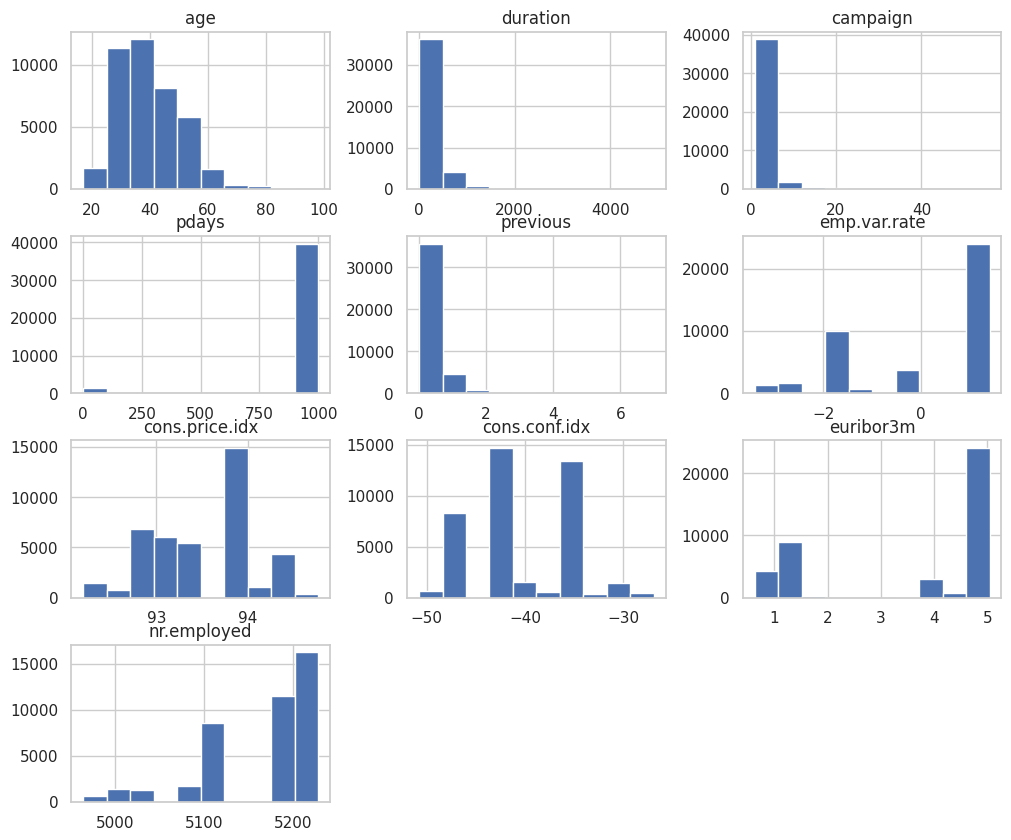

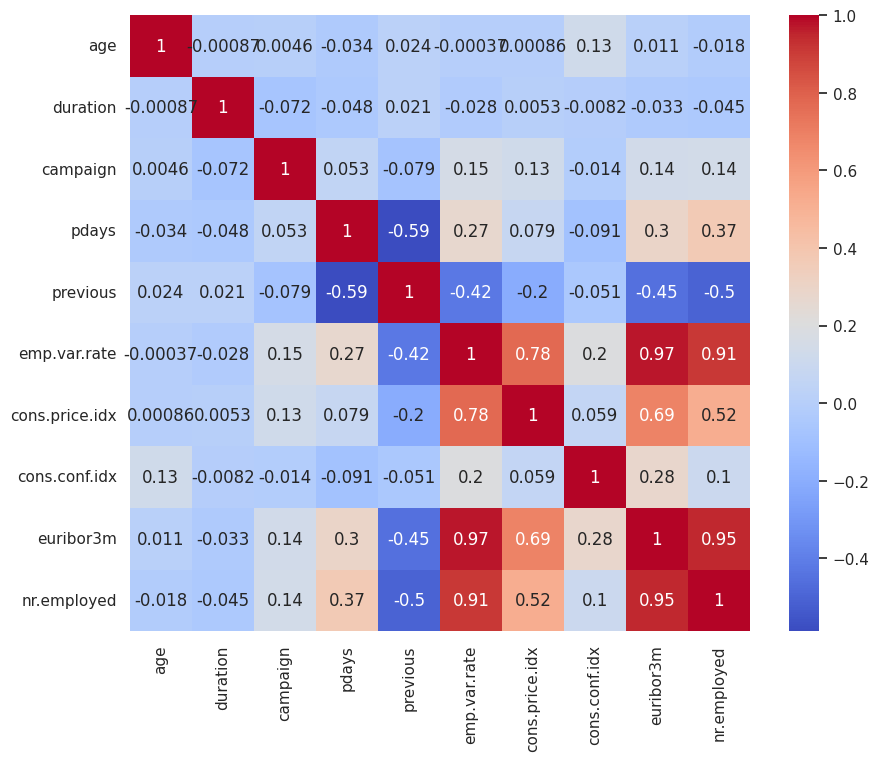

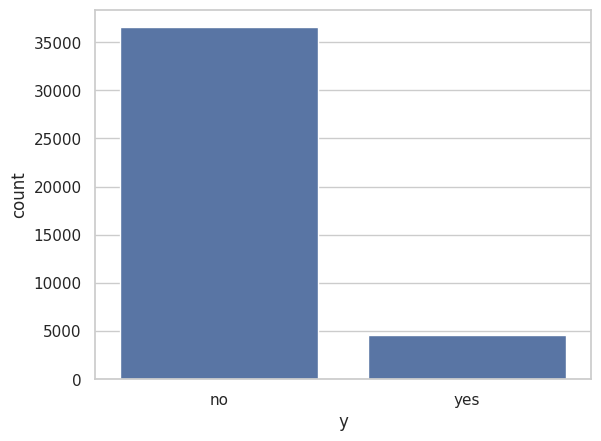

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


In [ ]:

# numerical distribution
df[num_cols].hist(figsize=(12,10))
plt.show()

# correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

# target distribution (assuming 'y')
if 'y' in df.columns:
    sns.countplot(x='y', data=df)
    plt.show()
    print(df['y'].value_counts(normalize=True))


In [ ]:

# Age grouping (if exists)
if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'],
                            bins=[0,25,40,60,100],
                            labels=['young','adult','middle','senior'])

# Log transform balance (if exists)
if 'balance' in df.columns:
    df['balance_log'] = np.log1p(df['balance'])


In [ ]:

def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

if 'balance' in df.columns:
    df = remove_outliers(df, 'balance')


In [ ]:

# encode target
if 'y' in df.columns:
    df['y'] = df['y'].map({'yes':1, 'no':0})

# one-hot encoding categorical
df = pd.get_dummies(df, drop_first=True)


In [ ]:

if 'y' in df.columns:
    X = df.drop('y', axis=1)
    y = df['y']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)


Train shape: (32950, 56)
Test shape: (8238, 56)


In [ ]:

scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_group_adult,age_group_middle,age_group_senior
12556,-0.001669,-0.631114,-0.206242,0.194661,-0.350902,0.838794,0.589080,-0.472769,0.771354,0.842874,...,False,True,False,False,False,True,False,True,False,False
35451,-0.864095,-0.546321,0.513676,0.194661,-0.350902,-1.199440,-1.180760,-1.229916,-1.372028,-0.941864,...,False,True,False,False,False,True,False,True,False,False
30592,1.819007,-0.943306,1.233593,0.194661,1.677559,-1.199440,-1.180760,-1.229916,-1.308581,-0.941864,...,False,True,False,False,False,False,False,False,True,False
17914,0.285806,-0.631114,0.873635,0.194661,-0.350902,0.838794,0.589080,-0.472769,0.771930,0.842874,...,False,False,False,True,False,True,False,False,True,False
3315,-0.097494,0.332441,-0.206242,0.194661,-0.350902,0.647709,0.720307,0.890097,0.713674,0.330972,...,False,False,True,False,False,True,False,True,False,False


In [ ]:
df.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_group_adult,age_group_middle,age_group_senior
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,True,False,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,True,False,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,False,True,False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/Project ML/Models/processed_bank_data.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.info()